**Objective**

To Build a Convolutional Autoencoders (CAE) that compress facial images into a lower-dimensional latent representation and reconstructs with minimal loss of information

**Purpose**

A convulutional Autoencoder is an unsupervised deep learning model used for:
image Compression Image Reconstruction Feature Extraction Dimensionality Reduction
The encoder learns a compressed representation(latent space),while the decodder reconstrcts the orginal image from this compressed representaion.

In [ ]:
#librariies

import os   # for math calculation
import shutil  #for moving and copying data
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model


In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [ ]:
# List the contents of the dataset directory
files_in_dataset = os.listdir(path)
print("Files in the dataset directory:", files_in_dataset)

Files in the dataset directory: ['list_landmarks_align_celeba.csv', 'img_align_celeba', 'list_eval_partition.csv', 'list_attr_celeba.csv', 'list_bbox_celeba.csv']


In [ ]:
# Download dataset
path = kagglehub.dataset_download("jessicali9530/celebA-dataset")

print(path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
/kaggle/input/celeba-dataset


In [ ]:
source_folder = os.path.join(path, "img_align_celeba", "img_align_celeba")

# Destination folder
destination_folder = "celeba_small/faces"

# Create destination folder if it doesn't exist
os.makedirs(destination_folder, exist_ok=True)

# Copy first 5000 images
images = sorted(os.listdir(source_folder))[:5000]

for img in images:
    shutil.copy(
        os.path.join(source_folder, img),
        destination_folder
    )

print("Copied", len(images), "images")

Copied 5000 images


In [ ]:
#Data Processing

IMAGE_SIZE = (64,64)

BATCH_SIZE = 32

In [ ]:
datagen = ImageDataGenerator(rescale=1./255,validation_split=0.2)


In [ ]:
#Load Dataset


train_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"
)

Found 4000 images belonging to 1 classes.


In [ ]:
validation_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation"
)

Found 1000 images belonging to 1 classes.


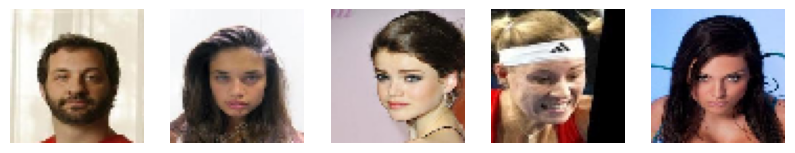

In [ ]:
#Display

images, _ = next(train_generator)

plt.figure(figsize=(10,5))

for i in range(5):
    ax = plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.axis("off")
plt.show()

In [ ]:
# Encoder
input_img = Input(shape=(64, 64, 3)) #64 * 64 and 3 is RGB

x = Conv2D(
    32,
    (3, 3),     # applying filter
    activation='relu',
    padding='same'
)(input_img)

x = MaxPooling2D(
    (2, 2),
    padding='same'
)(x)

x = Conv2D(
    64,
    (3, 3),
    activation='relu',
    padding='same'
)(x)

x = MaxPooling2D(
    (2, 2),
    padding='same'
)(x)

# Encoded representation
encoded = x

In [ ]:
# Decoder

x = Conv2D(
    64,
    (3, 3),
    activation='relu',
    padding='same'
)(encoded)

x = UpSampling2D((2, 2))(x)
# 16 × 16 → 32 × 32

x = Conv2D(
    32,
    (3, 3),
    activation='relu',
    padding='same'
)(x)

x = UpSampling2D((2, 2))(x)
# 32 × 32 → 64 × 64

decoded = Conv2D(
    3,
    (3, 3),
    activation='sigmoid',
    padding='same'
)(x)

In [ ]:
# Create Model

autoencoder = Model(
    input_img,
    decoded
)

In [ ]:
#Compile Model
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [ ]:
#Model Summary

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Train Model
history =autoencoder.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - loss: 0.5255 - val_loss: 0.4958
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.4924 - val_loss: 0.4900
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.4884 - val_loss: 0.4868
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.4861 - val_loss: 0.4856
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.4851 - val_loss: 0.4855
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.4843 - val_loss: 0.4839
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.4837 - val_loss: 0.4837
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 0.4834 - val_loss: 0.4840
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.4827 - val_loss: 0.4826
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.4825 - val_loss: 0.4827


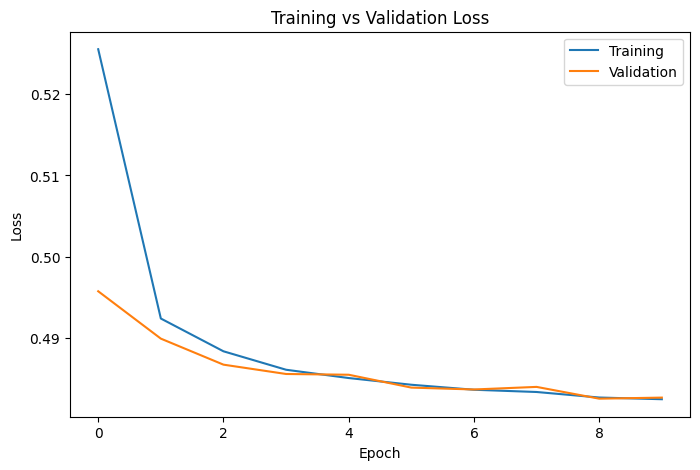

In [ ]:
#Plot  Loss

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("Training vs Validation Loss")
plt.legend(['Training', 'Validation'])
plt.show()

In [ ]:
#Evaluate
loss = autoencoder.evaluate(validation_generator)

print("Validation Loss:",loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.4827
Validation Loss: 0.48270976543426514


In [ ]:
#Reconstruct Images

images,_= next(validation_generator)

predictions = autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 912ms/step


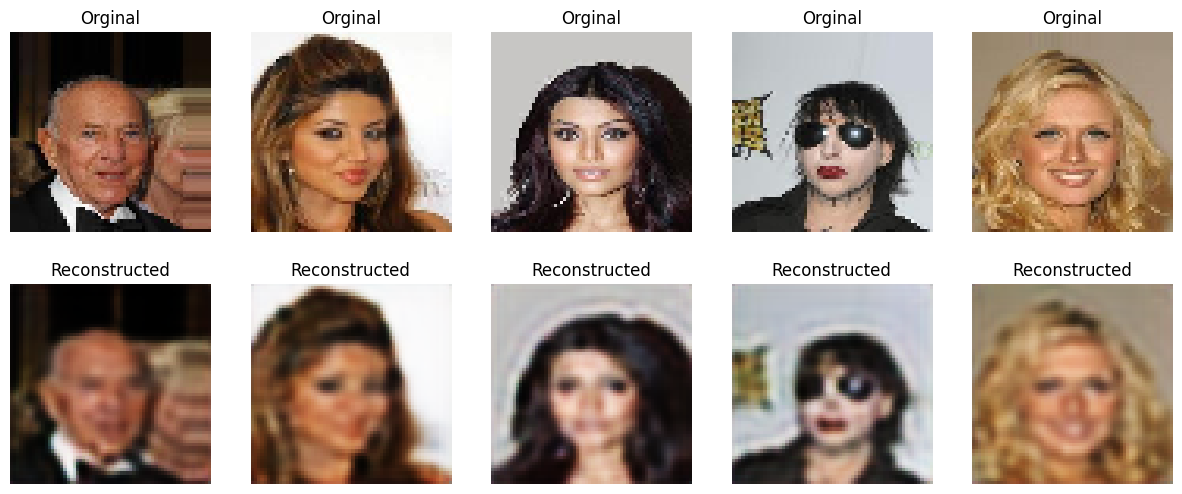

In [ ]:
#Display results

n = 5
plt.figure(figsize=(15,6))

for i in range(n):
    plt.subplot(2,n,i+1)
    plt.imshow(images[i])
    plt.title("Orginal")
    plt.axis("off")
    plt.subplot(2,n,i+n+1)
    plt.imshow(predictions[i])
    plt.title("Reconstructed")
    plt.axis("off")
plt.show()